# Volume of a Surface of Revolution (Spheroid Segment) via Gauss’ Theorem

**Geometry.** Consider an axisymmetric body generated by rotating the ellipse
$$
\left(\frac{\rho}{a_r}\right)^2 + \left(\frac{z}{b_z}\right)^2 = 1
$$
around the \(z\)-axis. The radial profile is
$$
\rho(z) = a_r \sqrt{1 - \frac{z^2}{b_z^2}}, \qquad z \in [-h,\, h],
$$
where \(a_r\) is the equatorial (radial) semi-axis and \(b_z\) is the polar (axial) semi-axis.

**Volume of the segment.** For the segment bounded by \(z=\pm h\) (\(0 < h \le b_z\)), the volume obtained via Gauss’/divergence theorem (or the surface of revolution integral) is
$$
V \;=\; \pi \!\int_{-h}^{h}\!\rho(z)^2\,dz
\;=\; 2\pi\,a_r^{\,2}\!\left(h-\frac{h^{3}}{3\,b_z^{\,2}}\right).
$$


**Notes.**
- $a_r$: equatorial semi-axis (in $x - y$ plane); $b_z$: polar semi-axis (along $z$).  
- The same formulas can be used to validate numerical quadrature $V \approx 2\pi\int \rho^2\,dz$.


Analytic volume  : 23.038346
Numeric volume   : 23.038084
Relative error   : 1.136e-05


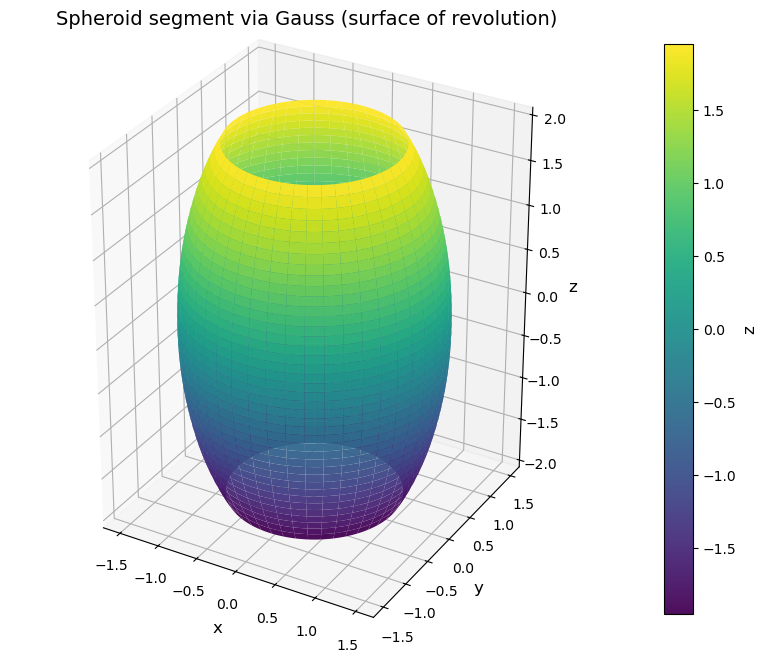

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -----------------------------
# Parameters (semi-axes & segment half-height)
# -----------------------------
h   = 2.0        # half-height of the segment along z
a_r = 1.5        # equatorial semi-axis (x/y)
b_z = h / np.sqrt(1.0 - 1.0/(a_r**2))  # polar semi-axis implied by h and a_r

# -----------------------------
# Axial sampling (z) and radial profile rho(z)
# -----------------------------
z = np.linspace(-h, h, 201)                         # axial positions
rho = a_r * np.sqrt(np.clip(1.0 - (z**2)/(b_z**2), 0.0, None))  # radial profile

# -----------------------------
# Analytic volume (Gauss / revolution integral)
# V = pi * ∫ rho(z)^2 dz = 2*pi*a_r^2*h*(1 - h^2/(3 b_z^2))
# -----------------------------
V_analytic = 2.0 * np.pi * a_r**2 * h * (1.0 - (h**2)/(3.0 * b_z**2))

# Numeric check via trapezoidal rule on the same grid
V_numeric =   np.pi * np.trapz(rho**2, z)
rel_err   = 0.0 if V_analytic == 0 else abs(V_numeric - V_analytic) / abs(V_analytic)
print(f"Analytic volume  : {V_analytic:.6f}")
print(f"Numeric volume   : {V_numeric:.6f}")
print(f"Relative error   : {rel_err:.3e}")

# -----------------------------
# 3D surface of revolution (phi sweep)
# -----------------------------
phi = np.linspace(0.0, 2.0*np.pi, 361)              # azimuthal angle
PHI, Zs = np.meshgrid(phi, z, indexing="xy")        # shapes: (len(z), len(phi))

R = rho[:, None]                                    # (len(z), 1) for broadcasting
X = R * np.cos(PHI)
Y = R * np.sin(PHI)
Z = Zs

# -----------------------------
# Plot
# -----------------------------
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X, Y, Z,
    cmap="viridis",
    linewidth=0, antialiased=True, shade=True, alpha=0.95
)

# Colorbar uses the default mapped values (here Z); label accordingly
cbar = fig.colorbar(surf, shrink=0.85, pad=0.08)
cbar.set_label("z", fontsize=12)

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('z', fontsize=12)
ax.set_title('Spheroid segment via Gauss (surface of revolution)', fontsize=14)

# Equal-looking aspect
# ratio ≈ span_z / span_xy; use max radius for XY span
span_xy = 2.0 * np.max(rho) if np.max(rho) > 0 else 1.0
span_z  = 2.0 * h
ax.set_box_aspect((span_xy, span_xy, span_z))

# Optional grid & tight layout
plt.grid(False)
plt.tight_layout()
plt.show()
